# 02 Dataset Analysis using Word2Vec

This notebook analyses the cleaned Arabic summarisation datasets and trains a **Word2Vec** model to explore semantic relationships between Arabic words.

Main goals:
- Load cleaned datasets from `processed_data/`
- Inspect article and summary lengths
- Analyse frequent words
- Train a Word2Vec model on cleaned Arabic text
- Explore similar words
- Visualise word embeddings using PCA and t-SNE

> Run this notebook after completing `01_data_preprocessing.ipynb`.

In [5]:
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from gensim.models import Word2Vec


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## 1. Load Cleaned Dataset Files

This cell searches for cleaned CSV files inside `processed_data/`. If your files are saved somewhere else, change `PROCESSED_DATA_DIR`.

In [6]:
PROCESSED_DATA_DIR = Path("dataset/processed_data")

csv_files = sorted(PROCESSED_DATA_DIR.rglob("*.csv"))

print(f"Found {len(csv_files)} CSV files")
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")


Found 7 CSV files
0: dataset\processed_data\cleaned_Arabic_Text_Summarisation_data.csv
1: dataset\processed_data\cleaned_AraSum_AbsArSumCorpus_DW_article tab lead.csv
2: dataset\processed_data\cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001.csv
3: dataset\processed_data\SumArabic-ood.csv
4: dataset\processed_data\SumArabic-test.csv
5: dataset\processed_data\SumArabic-train.csv
6: dataset\processed_data\SumArabic-valid.csv


## 2. Combine Cleaned Files

In [9]:
dataframes = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    temp_df["source_file"] = file.stem
    print( temp_df["source_file"].unique())

    if "split" not in temp_df.columns:
        temp_df["split"] = file.stem

    dataframes.append(temp_df)

if len(dataframes) == 0:
    raise FileNotFoundError("No CSV files found. Make sure processed_data/ contains cleaned CSV files.")

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


['cleaned_Arabic_Text_Summarisation_data']
['cleaned_AraSum_AbsArSumCorpus_DW_article tab lead']
['cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001']
['SumArabic-ood']
['SumArabic-test']
['SumArabic-train']
['SumArabic-valid']
Combined dataset shape: (143042, 22)
Columns: ['Processed Text', 'summarizer', 'clean_article', 'clean_summary', 'article_tokens', 'summary_tokens', 'article_len', 'summary_len', 'source_file', 'split', 'article', 'summary', 'text', 'summarized_text', 'dataset', 'filename', 'length', 'offset', 'published', 'section', 'subdomain', 'url']


,Processed Text,summarizer,clean_article,clean_summary,article_tokens,summary_tokens,article_len,summary_len,source_file,split,...,text,summarized_text,dataset,filename,length,offset,published,section,subdomain,url
0,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,"['اشرف', 'رئيس', 'الجمهوريه', 'الباجي', 'قايد'...","['اشرف', 'رئيس', 'الجمهوريه', 'الباجي', 'قايد'...",80,26,cleaned_Arabic_Text_Summarisation_data,cleaned_Arabic_Text_Summarisation_data,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...",تحصل كتاب المصحف قراءاته الفه باحثون تونسيون م...,تحصل كتاب المصحف قراءاته الذي الفه باحثون تونس...,"['تحصل', 'كتاب', 'المصحف', 'قراءاته', 'الفه', ...","['تحصل', 'كتاب', 'المصحف', 'قراءاته', 'الذي', ...",52,28,cleaned_Arabic_Text_Summarisation_data,cleaned_Arabic_Text_Summarisation_data,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضره من جهه اخرى ستكون تونس حاضره في قائ...,"['احتضن', 'جناح', 'تونس', 'القريه', 'الدوليه',...","['تونس', 'حاضره', 'من', 'جهه', 'اخرى', 'ستكون'...",216,26,cleaned_Arabic_Text_Summarisation_data,cleaned_Arabic_Text_Summarisation_data,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,\nتنطلق فعاليات التظاهرة الموسيقية الالكترونية...,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,"['تنطلق', 'فعاليات', 'التظاهره', 'الموسيقيه', ...","['تنطلق', 'فعاليات', 'التظاهره', 'الموسيقيه', ...",64,14,cleaned_Arabic_Text_Summarisation_data,cleaned_Arabic_Text_Summarisation_data,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,وستلتأم خلال اليوم الثاني الندوة النقدية بعنوا...,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,ستلتام خلال اليوم الثاني الندوه النقديه بعنوان...,"['ينطلق', 'مهرجان', 'القيروان', 'للشعر', 'العر...","['ستلتام', 'خلال', 'اليوم', 'الثاني', 'الندوه'...",157,56,cleaned_Arabic_Text_Summarisation_data,cleaned_Arabic_Text_Summarisation_data,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Validate Required Columns

In [10]:
required_columns = ["clean_article", "clean_summary"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}. Please check preprocessing output.")

df = df.dropna(subset=["clean_article", "clean_summary"]).copy()
df = df[
    (df["clean_article"].astype(str).str.strip() != "") &
    (df["clean_summary"].astype(str).str.strip() != "")
].copy()

print("Dataset shape after validation:", df.shape)


Dataset shape after validation: (143041, 22)


## 4. Basic Dataset Overview

In [11]:
print("Number of samples:", len(df))

if "split" in df.columns:
    print("\nSamples by split:")
    display(df["split"].value_counts().to_frame("count"))

if "source_file" in df.columns:
    print("\nSamples by source file:")
    display(df["source_file"].value_counts().to_frame("count"))


Number of samples: 143041

Samples by split:


,count
split,
train,75816
cleaned_AraSum_AbsArSumCorpus_DW_article tab lead,49579
cleaned_Arabic_Text_Summarisation_data,5010
test,4174
valid,4121
cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001,3689
ood,652



Samples by source file:


,count
source_file,
SumArabic-train,75816
cleaned_AraSum_AbsArSumCorpus_DW_article tab lead,49579
cleaned_Arabic_Text_Summarisation_data,5010
SumArabic-test,4174
SumArabic-valid,4121
cleaned_Egyptian_Text_Summarisation_data_train-00000-of-00001,3689
SumArabic-ood,652


## 5. Tokenisation for Analysis

In [12]:
def tokenize_text(text):
    return str(text).split()

df["article_tokens"] = df["clean_article"].apply(tokenize_text)
df["summary_tokens"] = df["clean_summary"].apply(tokenize_text)

df["article_len"] = df["article_tokens"].apply(len)
df["summary_len"] = df["summary_tokens"].apply(len)

display(df[["clean_article", "clean_summary", "article_len", "summary_len"]].head())


,clean_article,clean_summary,article_len,summary_len
0,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,80,26
1,تحصل كتاب المصحف قراءاته الفه باحثون تونسيون م...,تحصل كتاب المصحف قراءاته الذي الفه باحثون تونس...,52,28
2,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضره من جهه اخرى ستكون تونس حاضره في قائ...,216,26
3,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,64,14
4,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,ستلتام خلال اليوم الثاني الندوه النقديه بعنوان...,157,56


## 6. Length Statistics

In [13]:
print("Article length statistics:")
display(df["article_len"].describe().to_frame().T)

print("Summary length statistics:")
display(df["summary_len"].describe().to_frame().T)


Article length statistics:


,count,mean,std,min,25%,50%,75%,max
article_len,143041.0,150.91722,204.967906,7.0,29.0,43.0,223.0,2827.0


Summary length statistics:


,count,mean,std,min,25%,50%,75%,max
summary_len,143041.0,17.809355,12.591036,2.0,8.0,10.0,32.0,62.0


## 7. Length Distributions

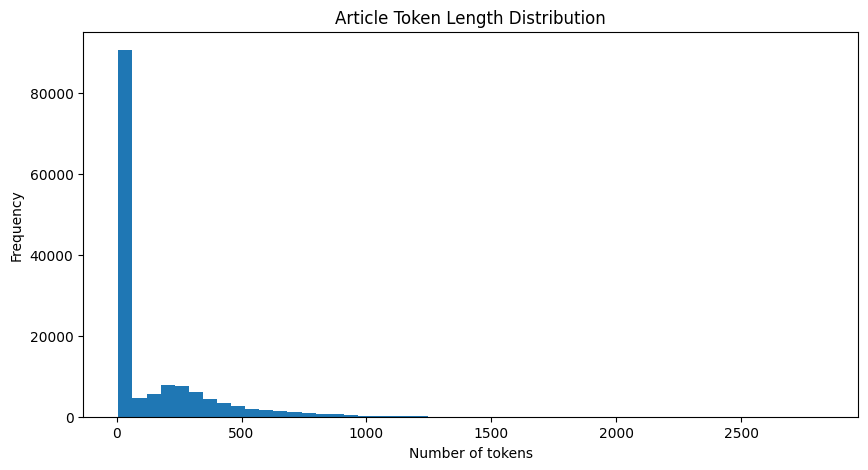

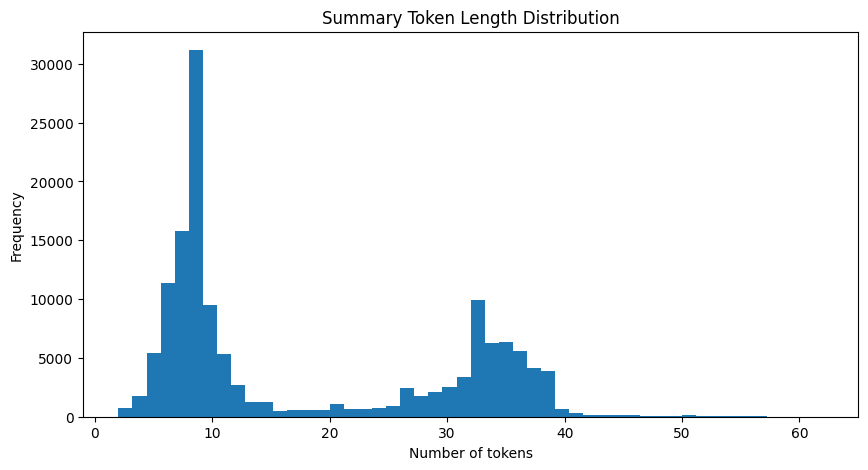

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["article_len"], bins=50)
plt.title("Article Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["summary_len"], bins=50)
plt.title("Summary Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()


## 8. Most Frequent Words

In [15]:
all_article_tokens = [token for tokens in df["article_tokens"] for token in tokens]
all_summary_tokens = [token for tokens in df["summary_tokens"] for token in tokens]

article_word_counts = Counter(all_article_tokens)
summary_word_counts = Counter(all_summary_tokens)

article_freq_df = pd.DataFrame(article_word_counts.most_common(30), columns=["word", "frequency"])
summary_freq_df = pd.DataFrame(summary_word_counts.most_common(30), columns=["word", "frequency"])

print("Top article words:")
display(article_freq_df)

print("Top summary words:")
display(summary_freq_df)


Top article words:


,word,frequency
0,في,873655
1,من,556347
2,ان,354753
3,على,345801
4,الى,241885
5,التي,136584
6,عن,132730
7,مع,103357
8,الذي,94875
9,ما,83769


Top summary words:


,word,frequency
0,في,106833
1,من,56792
2,على,41446
3,الى,25284
4,ان,23842
5,عن,17141
6,مع,12286
7,بعد,12018
8,التي,9541
9,بين,7602


## 9. Prepare Sentences for Word2Vec

In [16]:
word2vec_sentences = df["article_tokens"].tolist() + df["summary_tokens"].tolist()
word2vec_sentences = [tokens for tokens in word2vec_sentences if len(tokens) >= 3]

print("Number of sentences used for Word2Vec:", len(word2vec_sentences))
print("Example sentence tokens:")
print(word2vec_sentences[0][:30])


Number of sentences used for Word2Vec: 286071
Example sentence tokens:
['اشرف', 'رئيس', 'الجمهوريه', 'الباجي', 'قايد', 'السبسي', 'اليوم', 'بقصر', 'قرطاج', 'موكب', 'منح', 'الوسام', 'الوطني', 'للاستحقاق', 'الثقافي', 'الفنانين', 'المبدعين', 'بمناسبه', 'انعقاد', 'ايام', 'قرطاج', 'السينمائيه', 'الفنانون', 'الصنف', 'عبد', 'الرحمان', 'سيساكو', 'موريتانيا', 'جميل', 'راتب']


## 10. Train Word2Vec Model

Important parameters:
- `vector_size`: embedding dimension
- `window`: context window size
- `min_count`: ignores rare words
- `sg=1`: Skip-gram model
- `sg=0`: CBOW model

In [17]:
word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

print("Vocabulary size:", len(word2vec_model.wv))


Vocabulary size: 144470


## 11. Explore Similar Words

In [18]:
query_word = "الصحه"  # change this word based on your dataset vocabulary

if query_word in word2vec_model.wv:
    similar_words = word2vec_model.wv.most_similar(query_word, topn=10)
    similar_df = pd.DataFrame(similar_words, columns=["word", "similarity"])
    display(similar_df)
else:
    print(f"'{query_word}' not found in Word2Vec vocabulary.")
    print("Try one of these frequent words:")
    print(article_freq_df["word"].head(20).tolist())


,word,similarity
0,وقايه,0.743966
1,تعميمين,0.679439
2,زاره,0.659579
3,الصحيه,0.654732
4,للصحه,0.650029
5,تعاميم,0.646508
6,الزراعه,0.637915
7,صحه,0.622800
8,البيئه,0.617306
9,كيرياكيديس,0.608396


## 12. Word Similarity Function

In [19]:
def show_similar_words(word, topn=10):
    if word not in word2vec_model.wv:
        print(f"'{word}' not found in vocabulary.")
        return None

    results = word2vec_model.wv.most_similar(word, topn=topn)
    result_df = pd.DataFrame(results, columns=["word", "similarity"])
    display(result_df)
    return result_df

show_similar_words("الرييس", topn=10)


'الرييس' not found in vocabulary.


## 13. Compare Word Similarity Scores

In [20]:
word_pairs = [
    ("الرئيس", "الحكومه"),
    ("الصحه", "المرض"),
    ("اقتصاد", "السوق"),
]

for word1, word2 in word_pairs:
    if word1 in word2vec_model.wv and word2 in word2vec_model.wv:
        score = word2vec_model.wv.similarity(word1, word2)
        print(f"Similarity({word1}, {word2}) = {score:.4f}")
    else:
        print(f"Skipping ({word1}, {word2}) because one or both words are missing from vocabulary.")


Similarity(الرئيس, الحكومه) = 0.3902
Similarity(الصحه, المرض) = 0.4426
Similarity(اقتصاد, السوق) = 0.5727


## 14. Visualise Word Embeddings with PCA

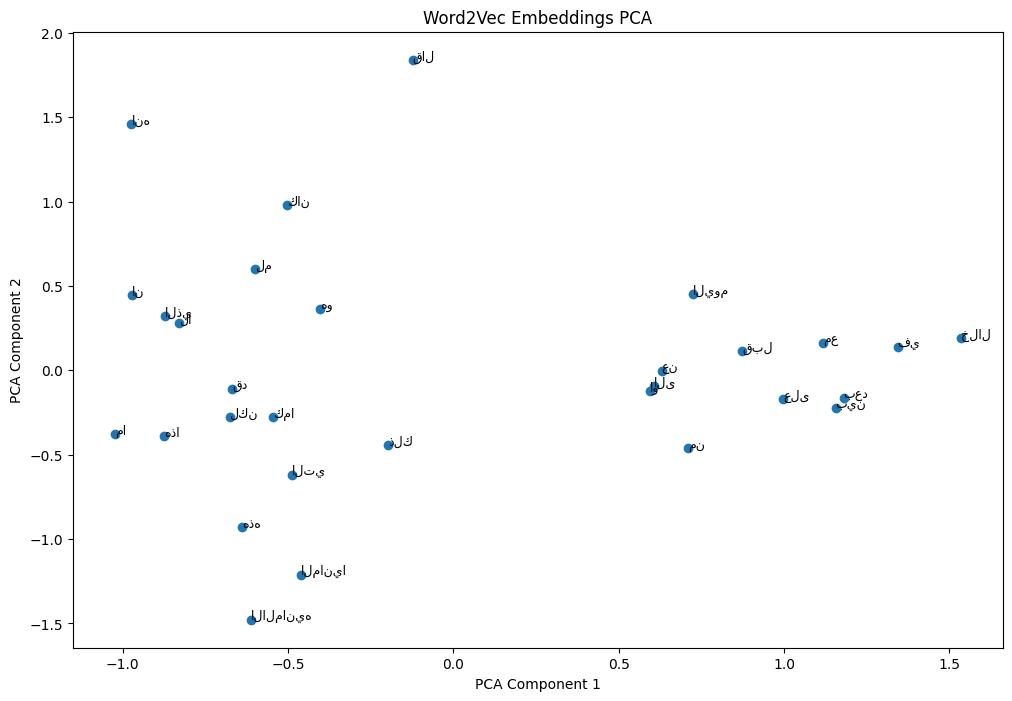

In [21]:
def plot_embeddings_pca(model, words, title="Word2Vec Embeddings PCA"):
    valid_words = [word for word in words if word in model.wv]

    if len(valid_words) < 2:
        print("Not enough valid words to plot.")
        return

    vectors = np.array([model.wv[word] for word in valid_words])
    pca = PCA(n_components=2, random_state=42)
    reduced_vectors = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

most_common_words = article_freq_df["word"].head(40).tolist()
plot_embeddings_pca(word2vec_model, most_common_words)


## 15. Visualise Word Embeddings with t-SNE

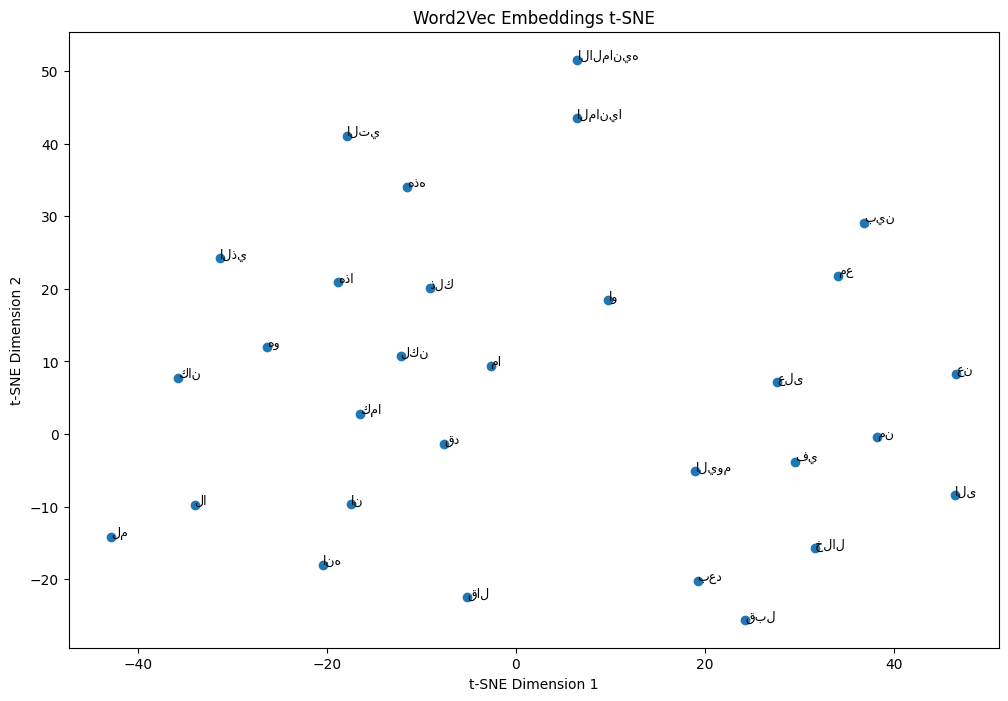

In [22]:
def plot_embeddings_tsne(model, words, title="Word2Vec Embeddings t-SNE"):
    valid_words = [word for word in words if word in model.wv]

    if len(valid_words) < 5:
        print("Not enough valid words to plot.")
        return

    vectors = np.array([model.wv[word] for word in valid_words])
    perplexity = min(10, len(valid_words) - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    reduced_vectors = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

plot_embeddings_tsne(word2vec_model, most_common_words)


## 16. Save Word2Vec Model

In [23]:
MODEL_DIR = Path("./results/word2vec")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "arabic_word2vec.model"
word_vectors_path = MODEL_DIR / "arabic_word_vectors.kv"

word2vec_model.save(str(model_path))
word2vec_model.wv.save(str(word_vectors_path))

print("Saved Word2Vec model to:", model_path.resolve())
print("Saved word vectors to:", word_vectors_path.resolve())


Saved Word2Vec model to: C:\Users\moham\Desktop\NLP_Project\results\word2vec\arabic_word2vec.model
Saved word vectors to: C:\Users\moham\Desktop\NLP_Project\results\word2vec\arabic_word_vectors.kv


## 17. Save Analysis Tables

In [24]:
ANALYSIS_DIR = Path("./results/dataset_analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

article_freq_df.to_csv(ANALYSIS_DIR / "top_article_words.csv", index=False, encoding="utf-8-sig")
summary_freq_df.to_csv(ANALYSIS_DIR / "top_summary_words.csv", index=False, encoding="utf-8-sig")

cols_to_save = [col for col in ["split", "source_file", "article_len", "summary_len"] if col in df.columns]
df[cols_to_save].to_csv(
    ANALYSIS_DIR / "length_statistics_by_sample.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved analysis outputs to:", ANALYSIS_DIR.resolve())


Saved analysis outputs to: C:\Users\moham\Desktop\NLP_Project\results\dataset_analysis


## 18. Notes for Report

You can describe this notebook in your report as follows:

- The cleaned Arabic article and summary texts were tokenised using whitespace tokenisation.
- Dataset statistics were calculated, including article and summary length distributions.
- A Word2Vec model was trained using Skip-gram to analyse semantic relationships between Arabic words.
- Similar-word queries and dimensionality reduction methods such as PCA and t-SNE were used to inspect learned word embeddings.

This analysis helps understand the vocabulary, common words, semantic clusters, and approximate text lengths before training the Seq2Seq summarisation model.